## Cab Cancellation Prediction - Point_to_Point
*Travel Type 2*

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows',500)
pd. set_option('display.max_columns',50) 
pd. set_option('display.width', 1000)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE


### 1. Import Data

In [2]:
data = pd.read_csv(r"D:\ML Project\Cab Cancellation\dataset\YourCabs.csv")

print(data.shape)
data.head()


(43431, 18)


,id,user_id,vehicle_model_id,travel_type_id,package_id,from_area_id,to_area_id,from_city_id,to_city_id,from_date,online_booking,mobile_site_booking,booking_created,from_lat,from_long,to_lat,to_long,Car_Cancellation
0,132512,22177,28,2,NaN,83.0,448.0,NaN,NaN,01-01-2013 02:00,0,0,01-01-2013 01:39,12.924150,77.672290,12.927320,77.635750,0
1,132513,21413,12,2,NaN,1010.0,540.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 02:25,12.966910,77.749350,12.927680,77.626640,0
2,132514,22178,12,2,NaN,1301.0,1034.0,NaN,NaN,01-01-2013 03:30,0,0,01-01-2013 03:08,12.937222,77.626915,13.047926,77.597766,0
3,132515,13034,12,2,NaN,768.0,398.0,NaN,NaN,01-01-2013 05:45,0,0,01-01-2013 04:39,12.989990,77.553320,12.971430,77.639140,0
4,132517,22180,12,2,NaN,1365.0,849.0,NaN,NaN,01-01-2013 09:00,0,0,01-01-2013 07:53,12.845653,77.677925,12.954340,77.600720,0


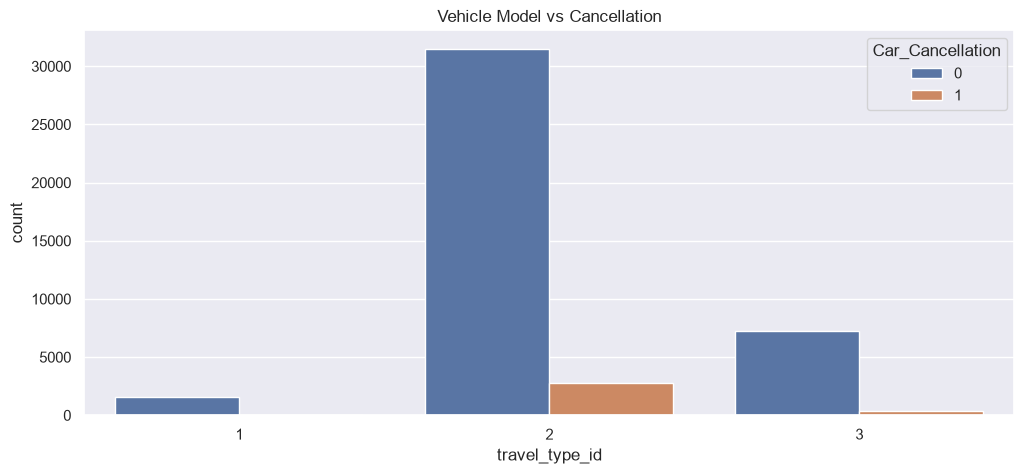

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=data,
    x='travel_type_id',
    hue='Car_Cancellation'
)

plt.title('Vehicle Model vs Cancellation')
plt.show()

### 2. Basic Preprocessing

In [10]:
data = data.drop(columns=['id', 'user_id'])

data['is_VMID_12'] = data['vehicle_model_id'].apply(
    lambda x: 1 if x == 12 else 0
)

data = data.drop(columns=['vehicle_model_id'])

data['from_city_id'] = data['from_city_id'].fillna(
    data['from_city_id'].mode()[0]
)

data['to_city_id'] = data['to_city_id'].fillna(
    data['to_city_id'].mode()[0]
)

data['from_area_id'] = data['from_area_id'].fillna(
    data['from_area_id'].mode()[0]
)


### 3. Feature Engineering

In [11]:
data['from_date'] = pd.to_datetime(
    data['from_date'], format='mixed'
)

data['booking_created'] = pd.to_datetime(
    data['booking_created'], format='mixed'
)

data['month'] = data['from_date'].dt.month
data['day_of_week'] = data['from_date'].dt.dayofweek

data['is_weekend'] = data['day_of_week'].apply(
    lambda x: 1 if x >= 5 else 0
)

data['time_diff'] = (
    data['from_date'] - data['booking_created']
).dt.total_seconds() / 3600

data['booking_nature'] = data['time_diff'].apply(
    lambda x: 0 if x <= 4 else 1 if x <= 24 else 2
)


### 4. Outlier Handling using IQR

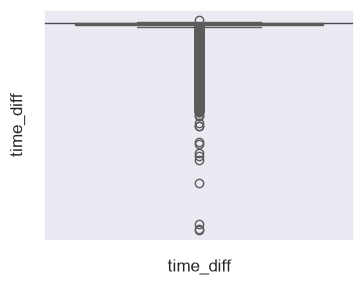

In [12]:
plt.figure(figsize=(4,3))
sns.boxplot(x = 'time_diff', data=data)
sns.boxplot(y = 'time_diff', data=data)
plt.show()

In [13]:
Q1 = data['time_diff'].quantile(0.25)
Q3 = data['time_diff'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[
    (data['time_diff'] >= lower) &
    (data['time_diff'] <= upper)
]

print(data.shape)


(37838, 21)


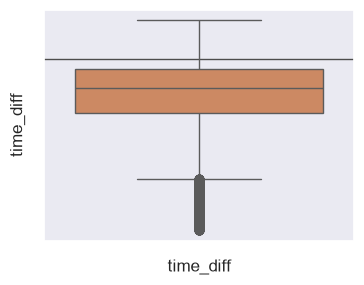

In [14]:
plt.figure(figsize=(4,3))
sns.boxplot(x = 'time_diff', data=data)
sns.boxplot(y = 'time_diff', data=data)
plt.show()

### 5. Area Cancellation Volume

In [15]:
area_info = data.groupby('from_area_id')['Car_Cancellation'].agg(
    ['count', 'mean']
)

def categorize(row):
    if row['count'] == 0:
        return 'Zero'
    elif row['mean'] < 0.05:
        return 'Low'
    elif row['mean'] < 0.15:
        return 'Medium'
    else:
        return 'High'

area_mapping = area_info.apply(categorize, axis=1)

data['area_cancellation_volume'] = (
    data['from_area_id'].map(area_mapping).fillna('Zero')
)

data['area_cancellation_volume'] = data[
    'area_cancellation_volume'
].map({
    'Zero': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3
})


### 6. Select Travel Type 2

In [16]:
d = data[data['travel_type_id'] == 2].copy()

d = d.drop(columns=['travel_type_id', 'package_id', 'from_date', 'booking_created', 'from_lat', 'from_long', 'to_lat', 'to_long', 'time_diff'])

d = d.fillna(0)

X = d.drop(columns=['Car_Cancellation'])
y = d['Car_Cancellation']

print(y.value_counts())

Car_Cancellation
0    27086
1     2483
Name: count, dtype: int64


### 7. Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### 8. Standardization

In [18]:
""" scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
 """

' scaler = StandardScaler()\n\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.transform(X_test)\n '

### 9. SMOTE

In [19]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train, y_train
)

print(y_train.value_counts())


Car_Cancellation
0    21669
1    21669
Name: count, dtype: int64


### 10. Logistic Regression

In [20]:
model = LogisticRegression()

model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [21]:
y_pred = model.predict(X_test)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7037538045316198


In [23]:
print(confusion_matrix(y_test, y_pred))

[[3873 1544]
 [ 208  289]]


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.71      0.82      5417
           1       0.16      0.58      0.25       497

    accuracy                           0.70      5914
   macro avg       0.55      0.65      0.53      5914
weighted avg       0.88      0.70      0.77      5914



### 11. Decision Tree

In [25]:
tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [26]:
tree_pred = tree.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, tree_pred))

Accuracy: 0.7394318566114305


In [28]:
print(confusion_matrix(y_test, tree_pred))

[[4162 1255]
 [ 286  211]]


In [29]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.94      0.77      0.84      5417
           1       0.14      0.42      0.21       497

    accuracy                           0.74      5914
   macro avg       0.54      0.60      0.53      5914
weighted avg       0.87      0.74      0.79      5914



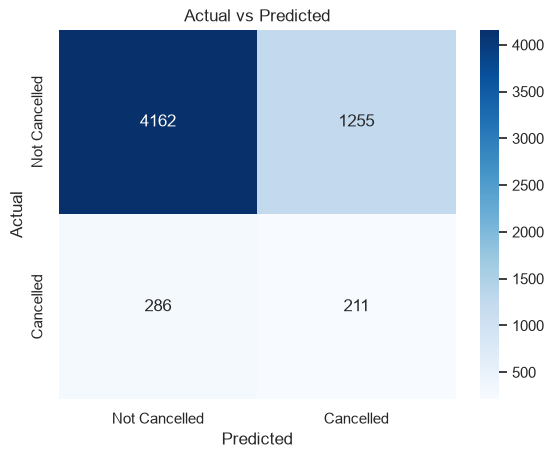

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, tree_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Cancelled', 'Cancelled'],
    yticklabels=['Not Cancelled', 'Cancelled']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Actual vs Predicted')
plt.show()